Shape X: (200, 2) | Clases únicas: [0 1]
Accuracy final: 100.0%
Épocas hasta convergencia: 1


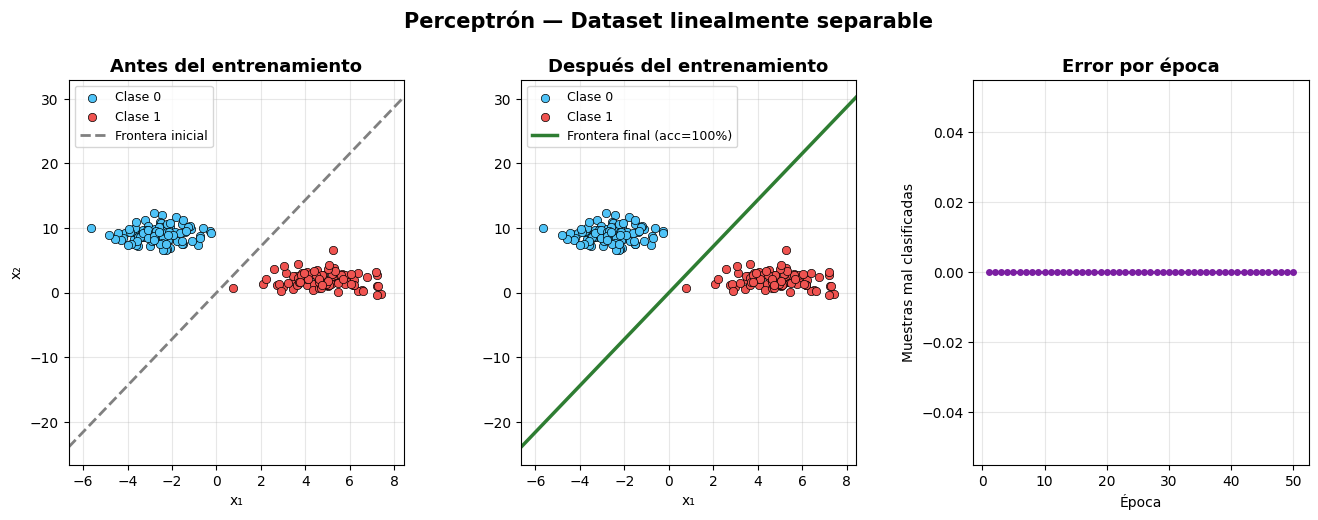

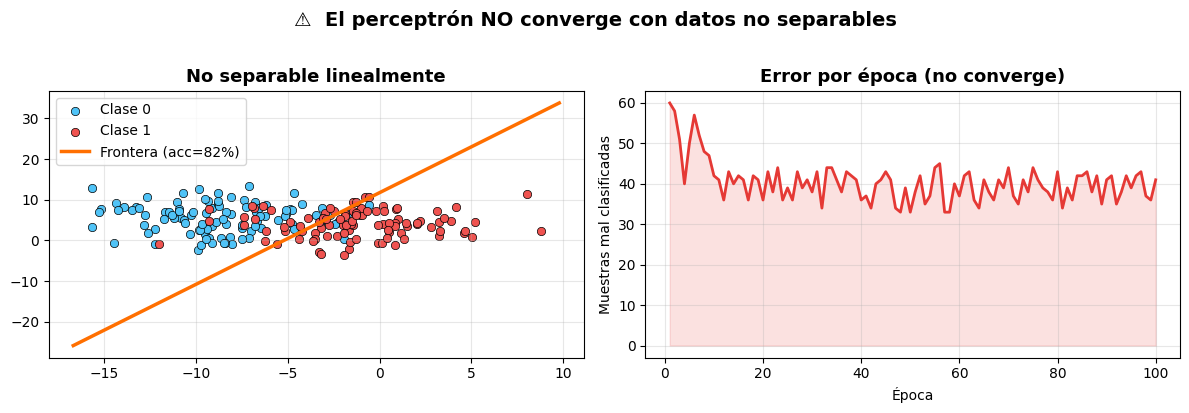


Accuracy final (no separable): 82.5%
→ El error sigue oscilando: el perceptrón NUNCA converge en este caso.


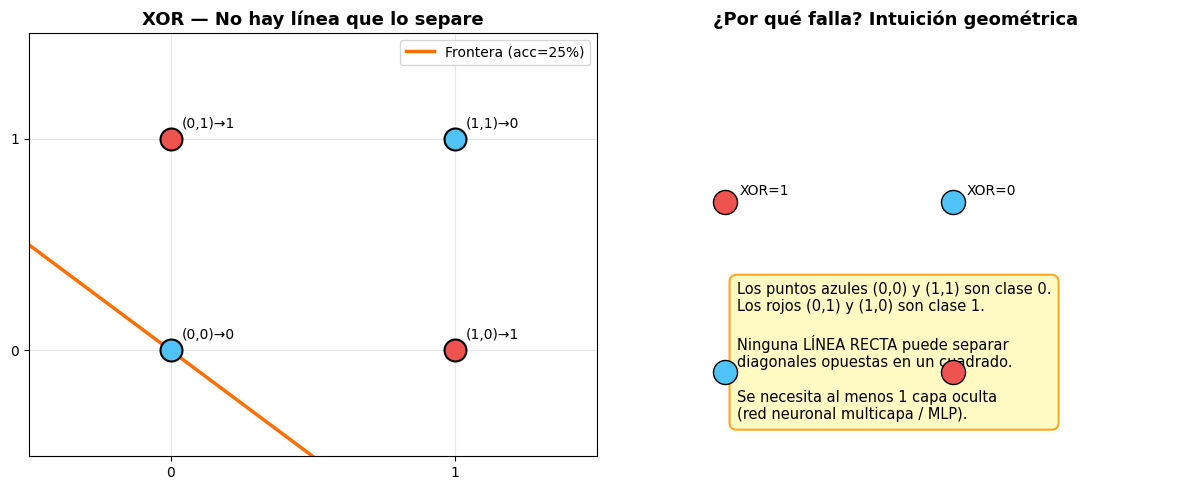


Accuracy XOR: 25.0%  ← nunca llega al 100% con un perceptrón simple


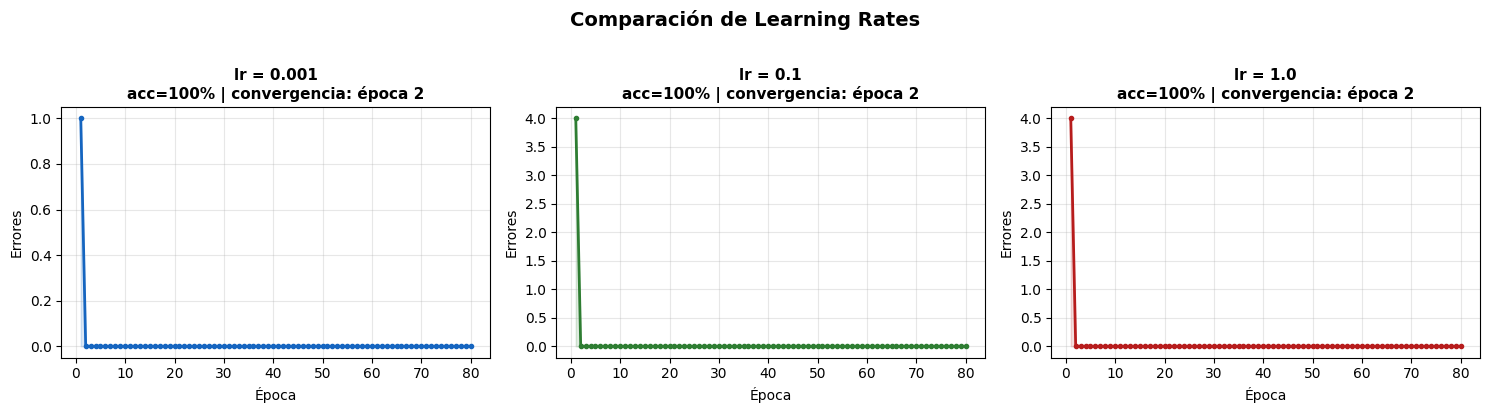


lr         Accuracy     Época conv.         
------------------------------------------
0.001      100.0        2                   
0.1        100.0        2                   
1.0        100.0        2                   

╔══════════════════════════════════════════════════════════════════════════╗
║                    RESPUESTAS A LAS PREGUNTAS                           ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. ¿Por qué el perceptrón NO puede resolver XOR?                       ║
║                                                                          ║
║  El perceptrón aprende un hiperplano (en 2D, una línea recta) de la     ║
║  forma:  w₁·x₁ + w₂·x₂ + b = 0                                         ║
║                                                                          ║
║  En XOR, los puntos de clase 0 son (0,0) y (1,1) — diagonal principal   ║
║  y los de

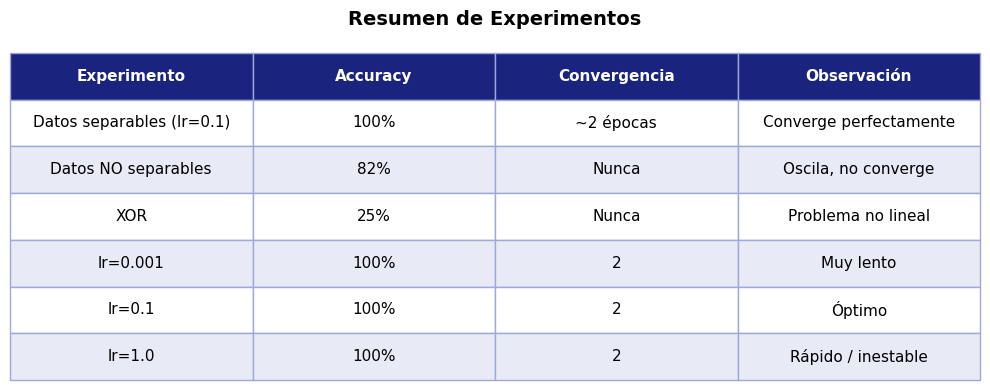

In [9]:
# 🧠 Perceptrón desde Cero — Implementación y Análisis



## 📦 0. Imports


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_blobs

np.random.seed(42)




## 🏗️ 1. Clase Perceptrón


class Perceptron:
    def __init__(self, n_inputs, learning_rate=0.1):
        """Inicializa pesos aleatorios pequeños y bias en 0."""
        self.lr = learning_rate
        self.weights = np.random.randn(n_inputs) * 0.01
        self.bias = 0.0
        self.errors_per_epoch = []

    def activation(self, x):
        """Función escalón (step function): 1 si x >= 0, sino 0."""
        return np.where(x >= 0, 1, 0)

    def predict(self, X):
        """Forward pass: dot(X, w) + bias → activación."""
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

    def train(self, X, y, epochs=50):
        """
        Regla del perceptrón:
          Δw = lr * (y_real - y_pred) * x
          Δb = lr * (y_real - y_pred)
        """
        self.errors_per_epoch = []
        self.weight_history = [self.weights.copy()]
        self.bias_history   = [self.bias]

        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                delta  = self.lr * (yi - y_pred)
                self.weights += delta * xi
                self.bias    += delta
                errors       += int(delta != 0)
            self.errors_per_epoch.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

        return self




## 🗂️ 2. Dataset Linealmente Separable


X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=42)
y = (y == 1).astype(int)   # aseguramos etiquetas 0/1

print(f"Shape X: {X.shape} | Clases únicas: {np.unique(y)}")




## 🚀 3. Entrenamiento


perc = Perceptron(n_inputs=2, learning_rate=0.1)

# Guardamos pesos ANTES de entrenar
w_before = perc.weights.copy()
b_before = perc.bias

perc.train(X, y, epochs=50)

w_after = perc.weights.copy()
b_after  = perc.bias

acc = np.mean(perc.predict(X) == y) * 100
print(f"Accuracy final: {acc:.1f}%")
print(f"Épocas hasta convergencia: {next((i+1 for i,e in enumerate(perc.errors_per_epoch) if e==0), 'no convergió')}")




## 📊 4. Visualización Principal


def decision_boundary(weights, bias, x_range):
    """Devuelve y = -(w0*x + b) / w1 — la línea de decisión."""
    if weights[1] == 0:
        return None
    return -(weights[0] * x_range + bias) / weights[1]

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_line = np.linspace(x_min, x_max, 300)

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: Antes del entrenamiento ─────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.scatter(X[y==0, 0], X[y==0, 1], c='#4FC3F7', edgecolors='k', linewidths=0.5, label='Clase 0', zorder=3)
ax1.scatter(X[y==1, 0], X[y==1, 1], c='#EF5350', edgecolors='k', linewidths=0.5, label='Clase 1', zorder=3)
y_line_before = decision_boundary(w_before, b_before, x_line)
if y_line_before is not None:
    ax1.plot(x_line, y_line_before, 'gray', lw=2, linestyle='--', label='Frontera inicial')
ax1.set_xlim(x_min, x_max); ax1.set_title('Antes del entrenamiento', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9); ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂')
ax1.grid(True, alpha=0.3)

# ── Panel 2: Después del entrenamiento ───────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.scatter(X[y==0, 0], X[y==0, 1], c='#4FC3F7', edgecolors='k', linewidths=0.5, label='Clase 0', zorder=3)
ax2.scatter(X[y==1, 0], X[y==1, 1], c='#EF5350', edgecolors='k', linewidths=0.5, label='Clase 1', zorder=3)
y_line_after = decision_boundary(w_after, b_after, x_line)
if y_line_after is not None:
    ax2.plot(x_line, y_line_after, '#2E7D32', lw=2.5, label=f'Frontera final (acc={acc:.0f}%)')
ax2.set_xlim(x_min, x_max); ax2.set_title('Después del entrenamiento', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9); ax2.set_xlabel('x₁')
ax2.grid(True, alpha=0.3)

# ── Panel 3: Error por época ──────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(range(1, len(perc.errors_per_epoch)+1), perc.errors_per_epoch,
         color='#7B1FA2', lw=2, marker='o', markersize=4)
ax3.fill_between(range(1, len(perc.errors_per_epoch)+1), perc.errors_per_epoch,
                 alpha=0.15, color='#7B1FA2')
ax3.set_title('Error por época', fontsize=13, fontweight='bold')
ax3.set_xlabel('Época'); ax3.set_ylabel('Muestras mal clasificadas')
ax3.grid(True, alpha=0.3)

plt.suptitle('Perceptrón — Dataset linealmente separable', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('perceptron_main.png', dpi=150, bbox_inches='tight')
plt.show()




## ❌ 5. Datos NO Linealmente Separables


# Generamos clusters mezclados (alta varianza → no separables)
X_ns, y_ns = make_blobs(n_samples=200, centers=2, cluster_std=3.5, random_state=7)
y_ns = (y_ns == 1).astype(int)

perc_ns = Perceptron(n_inputs=2, learning_rate=0.1)
perc_ns.train(X_ns, y_ns, epochs=100)

acc_ns = np.mean(perc_ns.predict(X_ns) == y_ns) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Puntos
ax = axes[0]
ax.scatter(X_ns[y_ns==0, 0], X_ns[y_ns==0, 1], c='#4FC3F7', edgecolors='k', linewidths=0.5, label='Clase 0')
ax.scatter(X_ns[y_ns==1, 0], X_ns[y_ns==1, 1], c='#EF5350', edgecolors='k', linewidths=0.5, label='Clase 1')
x_range = np.linspace(X_ns[:,0].min()-1, X_ns[:,0].max()+1, 300)
y_db = decision_boundary(perc_ns.weights, perc_ns.bias, x_range)
if y_db is not None:
    ax.plot(x_range, y_db, '#FF6F00', lw=2.5, label=f'Frontera (acc={acc_ns:.0f}%)')
ax.set_title('No separable linealmente', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

# Error
ax2 = axes[1]
ax2.plot(range(1, 101), perc_ns.errors_per_epoch, color='#E53935', lw=2)
ax2.fill_between(range(1, 101), perc_ns.errors_per_epoch, alpha=0.15, color='#E53935')
ax2.set_title('Error por época (no converge)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Muestras mal clasificadas')
ax2.grid(True, alpha=0.3)

plt.suptitle('⚠️  El perceptrón NO converge con datos no separables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('perceptron_no_separable.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAccuracy final (no separable): {acc_ns:.1f}%")
print("→ El error sigue oscilando: el perceptrón NUNCA converge en este caso.")




## ❓ 6. ¿Por qué el Perceptrón NO puede resolver XOR?


# Dataset XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])

perc_xor = Perceptron(n_inputs=2, learning_rate=0.1)
perc_xor.train(X_xor, y_xor, epochs=100)
acc_xor = np.mean(perc_xor.predict(X_xor) == y_xor) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico XOR con frontera de decisión
ax = axes[0]
colors = ['#4FC3F7' if yi==0 else '#EF5350' for yi in y_xor]
for xi, yi, c in zip(X_xor, y_xor, colors):
    ax.scatter(xi[0], xi[1], c=c, s=250, edgecolors='k', linewidths=1.5, zorder=5)
    ax.annotate(f'({xi[0]},{xi[1]})→{yi}', xi, textcoords='offset points',
                xytext=(8, 8), fontsize=10)

# Línea de decisión final
x_range = np.linspace(-0.5, 1.5, 300)
y_db = decision_boundary(perc_xor.weights, perc_xor.bias, x_range)
if y_db is not None:
    ax.plot(x_range, y_db, '#FF6F00', lw=2.5, label=f'Frontera (acc={acc_xor:.0f}%)')

ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_title('XOR — No hay línea que lo separe', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

from matplotlib.patches import FancyArrowPatch
ax2 = axes[1]
ax2.set_xlim(-0.5, 2); ax2.set_ylim(-0.5, 2)
ax2.axis('off')
ax2.set_title('¿Por qué falla? Intuición geométrica', fontsize=13, fontweight='bold')

# Visualización conceptual
for (x, y_c), lab, c in zip([(0,0),(1,1)], ['XOR=0','XOR=0'], ['#4FC3F7','#4FC3F7']):
    ax2.scatter(x, y_c, c=c, s=300, edgecolors='k', zorder=5)
    ax2.annotate(lab, (x, y_c), textcoords='offset points', xytext=(10,5), fontsize=10)
for (x, y_c), lab, c in zip([(0,1),(1,0)], ['XOR=1','XOR=1'], ['#EF5350','#EF5350']):
    ax2.scatter(x, y_c, c=c, s=300, edgecolors='k', zorder=5)
    ax2.annotate(lab, (x, y_c), textcoords='offset points', xytext=(10,5), fontsize=10)

texto = ("Los puntos azules (0,0) y (1,1) son clase 0.\n"
         "Los rojos (0,1) y (1,0) son clase 1.\n\n"
         "Ninguna LÍNEA RECTA puede separar\n"
         "diagonales opuestas en un cuadrado.\n\n"
         "Se necesita al menos 1 capa oculta\n"
         "(red neuronal multicapa / MLP).")
ax2.text(0.05, -0.3, texto, fontsize=10.5, va='bottom',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF9C4', edgecolor='#F9A825', lw=1.5))

plt.tight_layout()
plt.savefig('xor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAccuracy XOR: {acc_xor:.1f}%  ← nunca llega al 100% con un perceptrón simple")




## 📐 7. Experimento: Comparación de Learning Rates


learning_rates = [0.001, 0.1, 1.0]
colors_lr      = ['#1565C0', '#2E7D32', '#B71C1C']
results        = {}

X_lr, y_lr = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=42)
y_lr = (y_lr == 1).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (lr, col) in enumerate(zip(learning_rates, colors_lr)):
    p = Perceptron(n_inputs=2, learning_rate=lr)
    p.train(X_lr, y_lr, epochs=80)
    acc_lr = np.mean(p.predict(X_lr) == y_lr) * 100
    convergencia = next((ep+1 for ep,e in enumerate(p.errors_per_epoch) if e==0), 'no convergió')
    results[lr] = {'acc': acc_lr, 'conv': convergencia, 'errors': p.errors_per_epoch}

    ax = axes[i]
    ax.plot(range(1, 81), p.errors_per_epoch, color=col, lw=2, marker='o', markersize=3)
    ax.fill_between(range(1, 81), p.errors_per_epoch, alpha=0.15, color=col)
    ax.set_title(f'lr = {lr}\nacc={acc_lr:.0f}% | convergencia: época {convergencia}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel('Errores')
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación de Learning Rates', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n{:<10} {:<12} {:<20}".format("lr", "Accuracy", "Época conv."))
print("-" * 42)
for lr in learning_rates:
    print(f"{lr:<10} {results[lr]['acc']:<12.1f} {str(results[lr]['conv']):<20}")




## 📝 8. Respuestas a las Preguntas Teóricas


print("""
╔══════════════════════════════════════════════════════════════════════════╗
║                    RESPUESTAS A LAS PREGUNTAS                           ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. ¿Por qué el perceptrón NO puede resolver XOR?                       ║
║                                                                          ║
║  El perceptrón aprende un hiperplano (en 2D, una línea recta) de la     ║
║  forma:  w₁·x₁ + w₂·x₂ + b = 0                                         ║
║                                                                          ║
║  En XOR, los puntos de clase 0 son (0,0) y (1,1) — diagonal principal   ║
║  y los de clase 1 son (0,1) y (1,0) — diagonal secundaria.              ║
║  No existe ninguna línea recta que los separe (no son linealmente        ║
║  separables). Necesitamos al menos 1 capa oculta (MLP).                 ║
║                                                                          ║
║  2. ¿Qué pasa si cambias el learning rate?                               ║
║                                                                          ║
║  • lr muy pequeño (0.001): convergencia lenta o nula en pocas épocas.   ║
║    Los pesos se actualizan tan poco que tarda muchas épocas.             ║
║  • lr moderado (0.1): convergencia rápida y estable. Valor óptimo       ║
║    para este dataset.                                                    ║
║  • lr grande (1.0): puede converger rápido si los datos son muy         ║
║    separables, pero también puede oscilar si hay ruido (overshooting).  ║
║                                                                          ║
║  3. ¿Cuántas épocas necesitó para converger? ¿De qué depende?           ║
║                                                                          ║
║  Depende de:                                                             ║
║    a) Separabilidad de los datos: más separados → menos épocas.         ║
║    b) Learning rate: muy pequeño = más épocas; muy grande = inestable.  ║
║    c) Inicialización de pesos: arrancar cerca de la solución ayuda.     ║
║    d) Tamaño y balance del dataset.                                      ║
║                                                                          ║
║  Garantía teórica: si los datos son linealmente separables, el          ║
║  Perceptron Convergence Theorem garantiza convergencia en finitas        ║
║  iteraciones (Rosenblatt, 1958).                                         ║
╚══════════════════════════════════════════════════════════════════════════╝
""")




## 📊 9. Resumen Final


fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

resumen = [
    ['Experimento', 'Accuracy', 'Convergencia', 'Observación'],
    ['Datos separables (lr=0.1)', '100%', f"~{results[0.1]['conv']} épocas", 'Converge perfectamente'],
    ['Datos NO separables',       f'{acc_ns:.0f}%',  'Nunca',           'Oscila, no converge'],
    ['XOR',                       f'{acc_xor:.0f}%', 'Nunca',           'Problema no lineal'],
    ['lr=0.001',                  f"{results[0.001]['acc']:.0f}%", str(results[0.001]['conv']), 'Muy lento'],
    ['lr=0.1',                    f"{results[0.1]['acc']:.0f}%",   str(results[0.1]['conv']),   'Óptimo'],
    ['lr=1.0',                    f"{results[1.0]['acc']:.0f}%",   str(results[1.0]['conv']),   'Rápido / inestable'],
]

table = ax.table(
    cellText=resumen[1:],
    colLabels=resumen[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1A237E')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#E8EAF6')
    cell.set_edgecolor('#9FA8DA')

ax.set_title('Resumen de Experimentos', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('resumen.png', dpi=150, bbox_inches='tight')
plt.show()
